# TS 2 — Where is the curve going?

**The brief.** Between July 2022 and October 2024 the yield curve was inverted for
28 consecutive months — the longest unbroken inversion in seventy years of data. It has
since un-inverted and now sits a little above zero. The desk wants a twelve-month view
with an honest error band, and wants to know whether the model is worth anything at all
against just quoting today's number.

You will work with the **slope** of the term structure, ten-year minus one-year:

$$\text{slope}_t = y^{(10)}_t - y^{(1)}_t$$

Five steps, the same five as the lecture: **stationary or not**, **which model**,
**is it adequate**, **what does it forecast**, **is it better than doing nothing**.

Each task below is small. Do them in order — later cells use names defined earlier.
Do not look up the answers before you have a number of your own; the point of the
exercise is to watch the evidence arrive.

> Data: `treasuries.csv` (GS1, GS5, GS10 constant-maturity yields), loaded straight
> from the web so this runs in Colab.

---
## Setup — run this and look at the picture

This one is done for you. Run it, then we discuss what is on the screen before anyone
writes any code. Your own work starts at Step 1 below.

1953-04 to 2026-08,  T = 881
latest +0.65%   mean +0.90%   sd 1.09%
inverted (slope < 0) in 18.8% of months


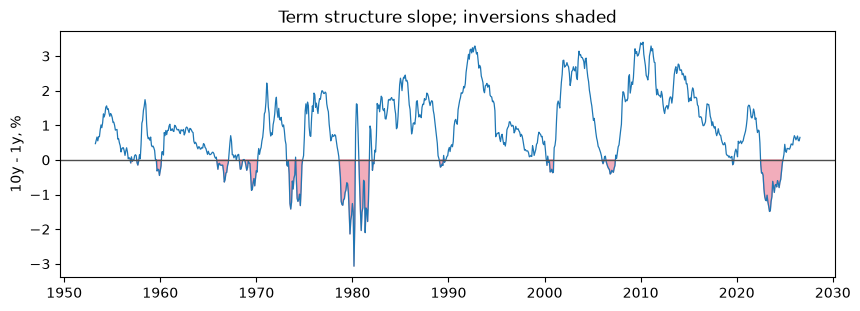

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf, adfuller, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

import warnings; warnings.simplefilter("ignore")

URL = "https://bashtage.github.io/summer-school/"

# Constant-maturity Treasury yields; the slope is ten-year minus one-year.
raw = pd.read_csv(URL + "treasuries.csv")
raw["date"] = pd.to_datetime(raw["date"], format="%Y%m%d")
yields = raw.set_index("date").sort_index().asfreq("MS")
slope = (yields["GS10"] - yields["GS1"]).dropna()
slope.name = "slope"
T = len(slope)

print(f"{slope.index[0]:%Y-%m} to {slope.index[-1]:%Y-%m},  T = {T}")
print(f"latest {slope.iloc[-1]:+.2f}%   mean {slope.mean():+.2f}%   sd {slope.std():.2f}%")
print(f"inverted (slope < 0) in {(slope < 0).mean():.1%} of months")

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(slope.index, slope, lw=0.9)
ax.axhline(0, color="0.3", lw=1.0)
ax.fill_between(slope.index, slope, 0, where=slope < 0, color="crimson", alpha=0.35)
ax.set_ylabel("10y - 1y, %"); ax.set_title("Term structure slope; inversions shaded")
plt.show()

**Look at the plot before moving on.** How many separate inversions can you count? Do
they look like they last a similar length of time? Is the recent one unusual?

---
# Step 1 — Stationary, or does it need differencing?

Slow decay in the autocorrelations is consistent with high persistence **and** with a
unit root, and the two demand opposite treatments — model in levels, or difference
first. You cannot tell them apart by eye, which is what the ADF test is for.

Its null hypothesis is a unit root, so **failing to reject is not evidence of
stationarity**. Only a rejection tells you something.

## Task 1 — ACF and PACF

Print the first six autocorrelations and partial autocorrelations side by side, together
with the $\pm 1.96/\sqrt{T}$ band.

**Key functions**

- `acf(series, nlags=6, fft=False)` — returns lags 0…6, so slice `[1:]` to drop lag 0
- `pacf(series, nlags=6)` — same convention
- the iid band is `1.96 / np.sqrt(T)`

In [ ]:
# Compute the band, the ACF and the PACF to six lags.


# Print them as a small table: lag, ACF, PACF.

---
## Task 2 — The augmented Dickey–Fuller test

Run ADF on the level of the series and on its first difference. Report the statistic,
the $p$-value and the number of lags chosen.

Write a small helper so you can call it twice — you will want it again in your own work.

**Key functions**

- `adfuller(series.dropna(), regression="c", autolag="AIC")`
  returns `(stat, pvalue, usedlag, nobs, critical_values, icbest)`
- `regression="c"` includes a constant but no trend, which is what a mean-reverting
  spread needs
- `series.diff()` for the first difference

In [ ]:
# A helper that runs ADF on one series and prints statistic, p-value and lag count.
def adf(s, label):
    ...


# Run it on the level and on the first difference.

**Before you go on, write down your conclusion.** Does the level reject? At what size?
Do you model the slope in levels, or do you difference it first? Say why in one sentence.

---
# Step 2 — Which model?

## Task 3 — Score a grid on both criteria

Fit every $\text{ARMA}(P,Q)$ for $P \le 4$ and $Q \le 2$, skipping $(0,0)$, and collect
the AIC and BIC for each. Some specifications will fail to converge — catch the exception
and move on.

**Key functions**

- `ARIMA(series, order=(P, 0, Q), trend="c").fit(method="statespace")`
- the fitted object exposes `.aic` and `.bic`
- collect rows into a list, then `pd.DataFrame(rows, columns=["P", "Q", "AIC", "BIC"])`
- wrap the fit in `try: ... except Exception: pass`

In [ ]:
# Loop over P in 0..4 and Q in 0..2, skipping (0,0).
# Fit each, and record P, Q, AIC and BIC.


# Build a DataFrame `g` from the rows and show the six best by AIC.

---
## Task 4 — Which model does each criterion pick?

Pull out the AIC-preferred and BIC-preferred orders, and print the penalty each criterion
charges per parameter.

**Key functions**

- `g.loc[g.AIC.idxmin(), ["P", "Q"]].astype(int)` — the row that minimizes AIC
- AIC charges 2 per parameter; BIC charges $\ln T$ — `np.log(T)`

Store the BIC pick as `bp, bq`; you carry that model through the rest of the notebook.

In [ ]:
# Extract the AIC pick as (ap, aq) and the BIC pick as (bp, bq).


# Print both picks and the two penalties per parameter.

**Do the two criteria agree?** If not, which takes the larger model, and is that what
the penalties would lead you to expect? Neither answer is *right* — they are answering
different questions. Write down what each one is optimizing.

---
# Step 3 — Is it adequate?

If the model has captured the dynamics, nothing should be left in the residuals.
Ljung–Box is the standard test. It assumes the shocks are **iid** — and yields are
plainly not, since volatility in the early 1980s bears no relation to volatility in the
2010s. So run a heteroskedasticity-robust version alongside it and compare.

## Task 5 — Fit the chosen model and take its residuals

**Key functions**

- `ARIMA(slope, order=(bp, 0, bq), trend="c").fit(method="statespace")`
- `.resid` on the fitted object
- drop the first `max(bp, bq)` residuals — they are the recursion warming up and are not
  comparable to the rest

In [ ]:
# Fit the BIC-selected model, and take the residuals with the warm-up dropped.

---
## Task 6 — Build the robust test

Write `robust_lm(resid, M)`: regress the residual on its own first $M$ lags, and jointly
test that every slope is zero, using a heteroskedasticity-robust covariance. Return the
$p$-value.

This is the same auxiliary-regression shape as the ARCH test — construct something that
should be unpredictable, regress it on things that should not predict it.

**Key functions**

- build a `DataFrame` with the residual and `M` lagged copies via `.shift(k)`, then
  `.dropna()`
- `sm.add_constant(X)`
- `sm.OLS(y, X).fit(cov_type="HC3")` — `HC3` is the robust covariance
- `fitted.f_test("l1 = 0, l2 = 0, ...")` — build that string with a join; the result has
  a `.pvalue`

In [ ]:
def robust_lm(resid, M):
    """Regress e_t on M own lags; joint test of all slopes, HC3 covariance."""
    ...

---
## Task 7 — Compare the two tests

For 6, 12 and 24 lags, print the Ljung–Box $p$-value next to the robust one.

**Key functions**

- `acorr_ljungbox(e, lags=[M], model_df=bp + bq, return_df=True)["lb_pvalue"].iloc[0]`
- `model_df` subtracts the estimated ARMA parameters from the degrees of freedom. Leave
  it out and the test is too generous

In [ ]:
# For M in (6, 12, 24), print M, the Ljung-Box p-value and the robust LM p-value.

**Read the two columns against each other.**

Where they disagree, which do you believe, and why? Where they agree, what does that
tell you? Is there a horizon at which you would say the model has genuinely failed?

Write your answer before moving on — this is the judgment the rest of the exercise
depends on.

---
# Step 4 — What does it forecast?

## Task 8 — Twelve months ahead, with an interval

Produce the twelve-month path and its 95% band, and print the values at $h = 1, 3, 6, 12$.

**Key functions**

- `fit.get_forecast(12)` on the fitted model
- `.predicted_mean` and `.conf_int()` on the result
- both are indexed 0…11 for $h = 1…12$, so `h - 1` gets horizon `h`

In [ ]:
# Forecast twelve months ahead and print h, the forecast, and the 95% bounds
# at horizons 1, 3, 6 and 12.

---
## Task 9 — How fast does a shock die out?

Fit a plain AR(1) as a benchmark and report its persistence, its long-run mean, and the
half-life of a shock.

**Key functions**

- `ARIMA(slope, order=(1, 0, 0), trend="c").fit(method="statespace")`
- `.params["ar.L1"]` and `.params["const"]`
- half-life is $\ln(0.5) / \ln(\hat\phi_1)$, in months

In [ ]:
# Fit the AR(1), then print phi, the long-run mean, and the half-life in months.

**Look hard at the lower bound of your twelve-month interval.** What does it say could
still happen? Would a forecast that quoted only the central number be telling the desk
the truth?

And compare the half-life against the twelve-month horizon. How much of the interval's
width is *predicted change*, and how much is just accumulated shock?

---
# Step 5 — Is it better than doing nothing?

This is the question in the brief. A model that fits beautifully in sample and cannot
beat last month's number is not worth running.

## Task 10 — Recursive one-step forecasts

Hold out the last 40% of the sample. Walk forward through it: at each date, estimate on
everything up to that point and forecast one month ahead. Re-estimate every 12 months
and filter forward in between — refitting every month is far slower and changes nothing.

**Key functions**

- `split = int(0.6 * T)` for the first forecast origin
- `ARIMA(slope.iloc[:i], order=(bp, 0, bq), trend="c").fit(method="statespace")`
- `res.apply(slope.iloc[:i], refit=False)` — re-filters with the parameters held fixed
- `res.forecast(1).iloc[0]`
- collect into `pd.Series(index=slope.index[split:], dtype=float)`

In [ ]:
# Walk forward from `split` to T, re-estimating every 12 observations and
# filtering forward in between. Store the one-step forecasts in `fcs`.

---
## Task 11 — Line the forecasts up against a random walk

The benchmark is "quote last month's number". Build both error series on the same dates.

**Key functions**

- the random walk forecast is `slope.shift(1)`
- align on the common index: `em.index.intersection(er.index)`
- RMSE is `np.sqrt((e**2).mean())`

In [ ]:
# Build the actuals (`act`) and the random-walk forecast (`rw`).


# Build the two error series -- `em` for the model, `er` for the random walk --
# and align them on their common dates. Later tasks use these names.


# Print how many forecasts you have, from when, and the two RMSEs.

---
## Task 12 — Diebold–Mariano

Is the RMSE difference real, or sampling noise? Test whether the mean loss *differential*
is zero.

The trick: regress the loss differential on a constant and test that the constant is
zero. Use HAC standard errors, because loss differentials are autocorrelated.

**Key functions**

- MSE differential: `em**2 - er**2`; MAE differential: `np.abs(em) - np.abs(er)`
- `sm.OLS(d, np.ones(len(d))).fit(cov_type="HAC", cov_kwds={"maxlags": 6})`
- `.tvalues.iloc[0]` and `.pvalues.iloc[0]`

A **negative** $t$ favors your model, since a negative differential means your loss is
the smaller one.

In [ ]:
# For both MSE and MAE, regress the loss differential on a constant with HAC
# standard errors, and print the t-statistic and p-value.

---
## Task 13 — Mincer–Zarnowitz

A different question: is the forecast *well calibrated*? Regress the actual on the
forecast and test $(\beta_1, \beta_2) = (0, 1)$ jointly.

**Key functions**

- `sm.OLS(actual, sm.add_constant(pd.DataFrame({"f": forecast})))`
- fit with `cov_type="HAC", cov_kwds={"maxlags": 6}`
- `.f_test("const = 0, f = 1")`, then `float(result.pvalue)`
- also report the $t$-statistic on $\hat\beta_2$ **against one**, not against zero:
  `(params["f"] - 1) / bse["f"]`

That last one matters. $\hat\beta_2 > 1$ and $\hat\beta_2 < 1$ mean opposite things
about the forecast, and a test against zero cannot see either.

In [ ]:
# Run the Mincer-Zarnowitz regression. Print b1, b2, the t-statistic on b2
# against one, and the joint p-value.

---
## Task 14 — Are the errors unpredictable?

An optimal one-step forecast has errors that cannot be forecast. Check.

**Key functions**

- `acf(em, nlags=1, fft=False)[1]` for the first autocorrelation
- `acorr_ljungbox(em, lags=[12], return_df=True)["lb_pvalue"].iloc[0]`
- no `model_df` here — you are testing the *forecast errors*, not the residuals of a
  fitted model

In [ ]:
# Print the first autocorrelation of the forecast errors and a Ljung-Box p-value
# at twelve lags.

---
# Write the answer to the brief

The desk asked three things. Answer them in your own words, with the numbers you
produced — not more than a short paragraph each.

**1. The number.** Your twelve-month central forecast and its 95% interval. Say
explicitly what the interval does and does not rule out.

**2. Is it better than doing nothing?** Quote the RMSE comparison and the
Diebold–Mariano result. Be honest about the size of the edge and the significance.

**3. Should they trust it?** Bring together the Mincer–Zarnowitz result, the sign of
$\hat\beta_2 - 1$, and the autocorrelation of the errors. If the forecast is
mis-calibrated, say in which direction and what that implies.

**One more.** Your two answers to (2) and (3) may point in opposite directions. If they
do, that is not a mistake — say what it means for whether the desk should use this
forecast, and what you would try next.